In [12]:
import numpy as np
import pandas as pd
import json

from sklearn.preprocessing import LabelEncoder

import os
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
# Import configuration file
tokens = json.load(open("/home/jupyterlab/Vectice/config/token_e.json"))

In [14]:
from vectice import autolog
autolog.config(api_token = tokens["VECTICE_API_TOKEN"], host = tokens["VECTICE_HOST"],phase = tokens["MDL_PHASE"])

Welcome, Eric Barre. You`re now successfully connected to Vectice.
Phase 'Demo Modeling' successfully retrieved.

For quick access to the Phase in the Vectice web app, visit:
https://app.vectice.com/browse/phase/PHA-7500

Autolog is continuously evolving to enhance supported libraries, environments, and functionalities to provide an improved user experience.
For detailed information, supported libraries and environments please consult the documentation: https://api-docs.vectice.com/reference/vectice/autolog/


## Read in Data

In [15]:
## For the baseline model, we are only going to select a subset of columns that would make sense for the business

from sklearn.model_selection import train_test_split

selected_columns = ['SK_ID_CURR','AMT_ANNUITY','AMT_CREDIT','AMT_INCOME_TOTAL','AMT_GOODS_PRICE','CNT_CHILDREN','CNT_FAM_MEMBERS',
           'DAYS_BIRTH','DAYS_EMPLOYED','DAYS_REGISTRATION','DAYS_ID_PUBLISH', 'EXT_SOURCE_2', 'EXT_SOURCE_3',"TARGET"]

# Training data
path_train = "/home/jupyterlab/Vectice/Field demos/Banking/current_application_preprocessed.csv"
application_cleaned_baseline = pd.read_csv(path_train)[selected_columns]
app_train_feat, app_test_feat = train_test_split(application_cleaned_baseline, test_size=0.15, random_state=42)




Training data shape:  (119840, 14)
Testing shape:  (21149, 13)
Testing target shape:  (21149,)


## Exploratory Data Analysis

### Examine the Distribution of the Target Column

In [ ]:

# Separate the target variable from the testing set

target_variable = 'TARGET'
app_test_feat_target = app_test_feat[target_variable]
app_test_feat = app_test_feat.drop(target_variable, axis=1)

# Print the shapes of the resulting dataframes
print('Training data shape: ', app_train_feat.shape)
print('Testing shape: ', app_test_feat.shape)
print('Testing target shape: ', app_test_feat_target.shape)

In [16]:
app_train_feat

,SK_ID_CURR,AMT_ANNUITY,AMT_CREDIT,AMT_INCOME_TOTAL,AMT_GOODS_PRICE,CNT_CHILDREN,CNT_FAM_MEMBERS,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,EXT_SOURCE_2,EXT_SOURCE_3,TARGET
18653,121749,36459.0,755190.0,180000.0,675000.0,2,4.0,31,1744,389.0,1881,0.736804,0.656158,0
10918,112711,14652.0,206059.5,90000.0,166500.0,0,1.0,53,1109,3631.0,2010,0.728145,NaN,0
110177,227791,13842.0,127350.0,225000.0,112500.0,1,3.0,37,4557,4535.0,3984,0.539038,0.109626,0
113497,231627,41215.5,1494000.0,472500.0,1494000.0,0,2.0,52,3413,1774.0,1166,0.558043,0.304672,0
67086,177795,22351.5,398016.0,135000.0,360000.0,0,2.0,57,365243,5218.0,3314,0.599026,0.542445,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110268,227897,13500.0,270000.0,202500.0,270000.0,2,4.0,43,104,5622.0,330,0.767108,0.372334,0
119879,239009,32602.5,675000.0,121500.0,675000.0,0,1.0,39,1124,3813.0,4134,0.617180,NaN,0
103694,220345,41463.0,1503000.0,202500.0,1503000.0,0,2.0,49,1557,8992.0,1651,0.656705,NaN,0
131932,253016,33025.5,1125000.0,450000.0,1125000.0,0,1.0,39,5929,5038.0,5123,0.608427,0.554947,0


## Encoding Categorical Variables

### Label Encoding and One-Hot Encoding

In [17]:
# Create a label encoder object
le = LabelEncoder()
le_count = 0

for col in app_train_feat:
    if app_train_feat[col].dtype == 'object':
        if len(list(app_train_feat[col].unique())) <= 2:
            le.fit(app_train_feat[col])
            app_train_feat[col] = le.transform(app_train_feat[col])
            app_test_feat[col] = le.transform(app_test_feat[col])

            le_count += 1

print('%d columns were label encoded.' % le_count)

0 columns were label encoded.


In [18]:
# one-hot encoding of categorical variables
app_train_feat = pd.get_dummies(app_train_feat)
app_test_feat = pd.get_dummies(app_test_feat)
train_labels = app_train_feat['TARGET']

app_train_feat, app_test_feat = app_train_feat.align(app_test_feat, join = 'inner', axis = 1)

app_train_feat['TARGET'] = train_labels


app_train_feat['DAYS_EMPLOYED_ANOM'] = app_train_feat["DAYS_EMPLOYED"] == 365243

app_train_feat['DAYS_EMPLOYED'].replace({365243: np.nan}, inplace = True)


app_test_feat['DAYS_EMPLOYED_ANOM'] = app_test_feat["DAYS_EMPLOYED"] == 365243
app_test_feat["DAYS_EMPLOYED"].replace({365243: np.nan}, inplace = True)
print('Training Features shape: ', app_train_feat.shape)
print('Testing Features shape: ', app_test_feat.shape)
print('There are %d anomalies in the test data out of %d entries' % (app_test_feat["DAYS_EMPLOYED_ANOM"].sum(), len(app_test_feat)))

Training Features shape:  (119840, 15)
Testing Features shape:  (21149, 14)
There are 3769 anomalies in the test data out of 21149 entries


In [19]:
def plot_feature_importances(features, feature_importance_values):

    df = pd.DataFrame({'feature': features, 'importance': feature_importance_values}).sort_values('importance', ascending = False).reset_index()
    df['importance_normalized'] = df['importance'] / df['importance'].sum()

    # Make a horizontal bar chart of feature importances
    plt.figure(figsize = (10, 6))
    ax = plt.subplot()

    # Need to reverse the index to plot most important on top
    ax.barh(list(reversed(list(df.index[:15]))),
            df['importance_normalized'].head(15),
            align = 'center', edgecolor = 'k')

    # Set the yticks and labels
    ax.set_yticks(list(reversed(list(df.index[:15]))))
    ax.set_yticklabels(df['feature'].head(15))

    # Plot labeling
    plt.xlabel('Normalized Importance');
    plt.title('Feature Importances')
    plt.tight_layout()
    plt.savefig('Feature Importances.png')
    plt.show()

## Feature Engineering

### Create some domain features

In [20]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Drop the target from the training data
if 'TARGET' in app_train_feat:
    train_no_missing = app_train_feat.drop(columns=['TARGET'])

# Separate 'SK_ID_CURR'
train_ids = train_no_missing['SK_ID_CURR']
test_ids = app_test_feat['SK_ID_CURR']

# Drop 'SK_ID_CURR' from the features list
train_no_missing = train_no_missing.drop(columns=['SK_ID_CURR'])
test_no_missing = app_test_feat.drop(columns=['SK_ID_CURR'])

# Define the features list without 'SK_ID_CURR'
features = list(train_no_missing.columns)

# Median imputation of missing values
imputer = SimpleImputer(strategy='median')
# Fit on the training data
imputer.fit(train_no_missing)

# Transform both training and testing data
train_no_missing = pd.DataFrame(imputer.transform(train_no_missing), columns=features)
test_no_missing = pd.DataFrame(imputer.transform(test_no_missing), columns=features)

# Standardize the features
scaler = StandardScaler()
# Fit on the training data
scaler.fit(train_no_missing)

# Transform both training and testing data
train_no_missing = pd.DataFrame(scaler.transform(train_no_missing), columns=features)
test_no_missing = pd.DataFrame(scaler.transform(test_no_missing), columns=features)

# Reattach 'SK_ID_CURR' to the DataFrames
train_no_missing['SK_ID_CURR'] = train_ids.values
test_no_missing['SK_ID_CURR'] = test_ids.values

# Set 'SK_ID_CURR' as the index
train_no_missing = train_no_missing.set_index('SK_ID_CURR')
test_no_missing = test_no_missing.set_index('SK_ID_CURR')

# Display the first few rows of the transformed training data
print(train_no_missing.head())
print(test_no_missing.head())

            AMT_ANNUITY  AMT_CREDIT  AMT_INCOME_TOTAL  AMT_GOODS_PRICE  \
SK_ID_CURR                                                               
121749         0.644573    0.387763          0.031120         0.369729   
112711        -0.855855   -0.974421         -0.224359        -1.004173   
227791        -0.911587   -1.169670          0.158859        -1.150074   
231627         0.971844    2.220470          0.861426         2.582562   
177795        -0.326092   -0.498250         -0.096620        -0.481361   

            CNT_CHILDREN  CNT_FAM_MEMBERS  DAYS_BIRTH  DAYS_EMPLOYED  \
SK_ID_CURR                                                             
121749          2.193229         2.027064   -1.035503      -0.234636   
112711         -0.579630        -1.270135    0.803345      -0.532329   
227791          0.806799         0.927997   -0.533999       1.084120   
231627         -0.579630        -0.171069    0.719761       0.547804   
177795         -0.579630        -0.171069    1.13

# Modeling

ROC AUC Score: 0.7277621302878317
F1 Score: 0.2704009098663634
Recall Score: 0.5446735395189003


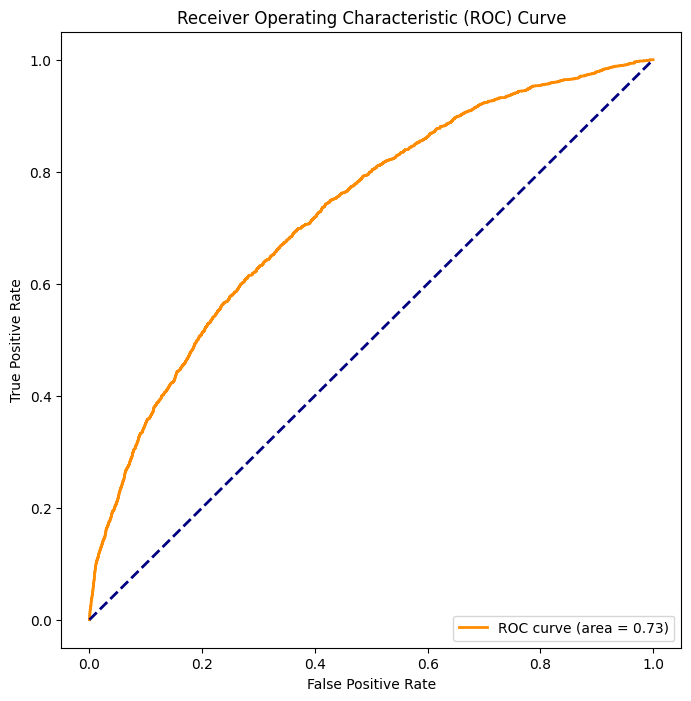

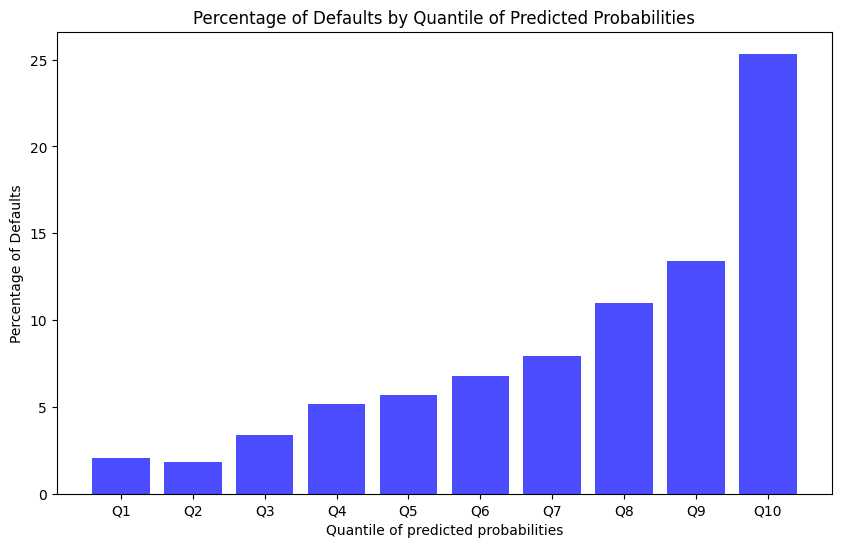

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score, recall_score, roc_curve, auc
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Define and train the logistic regression model
logistic_regression = LogisticRegression(random_state=50, solver='liblinear', max_iter=1000)
features = list(train_no_missing.columns)
# Train on the training data
logistic_regression.fit(train_no_missing, train_labels)

# Make predictions on the test data
predictions = logistic_regression.predict_proba(test_no_missing)[:, 1]

# Evaluate the model
roc_auc = roc_auc_score(app_test_feat_target.values, predictions)

sorted_indices = np.argsort(predictions)[::-1]
sorted_labels = app_test_feat_target.iloc[sorted_indices]

desired_percentage = 0.25

threshold_index = int(desired_percentage * len(predictions))
threshold_probability = predictions[sorted_indices[threshold_index]]
binary_predictions = (predictions >= threshold_probability).astype(int)

# Calculate the recall at the desired percentage
recall = recall_score(app_test_feat_target.values, binary_predictions)
f1 = f1_score(app_test_feat_target.values, binary_predictions)

# Print metrics
metric = {"auc": float(roc_auc),
          f"recall at {desired_percentage}%": float(recall),
          f"f1_score at {desired_percentage}%": float(f1)}

print("ROC AUC Score:", roc_auc)
print("F1 Score:", f1)
print("Recall Score:", recall)

# Plot ROC curve
fpr, tpr, thresholds = roc_curve(app_test_feat_target.values, predictions)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.savefig("roc_curve.png")
plt.show()

# Create a DataFrame with predicted probabilities and true labels
df_results = pd.DataFrame({'Probability': predictions, 'Default': app_test_feat_target.values})

# Sort instances based on predicted probabilities
df_results = df_results.sort_values(by='Probability', ascending=False)

# Divide the sorted instances into quantiles (e.g., deciles)
num_quantiles = 10
df_results['Quantile'] = pd.qcut(df_results['Probability'], q=num_quantiles, labels=False, duplicates='drop')

# Calculate the percentage of defaults in each quantile
quantile_defaults = df_results.groupby('Quantile')['Default'].mean() * 100

# Plot the results
plt.figure(figsize=(10, 6))
plt.bar(quantile_defaults.index, quantile_defaults.values, color='blue', alpha=0.7)
plt.xlabel('Quantile of predicted probabilities')
plt.ylabel('Percentage of Defaults')
plt.title('Percentage of Defaults by Quantile of Predicted Probabilities')
plt.xticks(ticks=quantile_defaults.index, labels=[f'Q{i + 1}' for i in quantile_defaults.index])
plt.savefig("Percentage_of_Defaults_by_Quantile.png")
plt.show()


In [22]:
autolog.notebook(note= "Baseline model logistic regression", capture_schema_only=False)

New Iteration 'Iteration 24' created.

For quick access to the Iteration in the Vectice web app, visit:
https://app.vectice.com/browse/iteration/ITR-15151
Note logged in iteration 'Iteration 24'.
File: /home/jupyterlab/Vectice/Field demos/Banking/current_application_preprocessed.csv wrapped successfully.
Dataset 'PHA-7500-application_cleaned_baseline' logged in iteration 'Iteration 24'.
Dataset 'PHA-7500-app_train_feat' logged in iteration 'Iteration 24'.
Dataset 'PHA-7500-app_test_feat' logged in iteration 'Iteration 24'.
Dataset 'PHA-7500-train_no_missing' logged in iteration 'Iteration 24'.
Dataset 'PHA-7500-test_no_missing' logged in iteration 'Iteration 24'.
Model 'PHA-7500-logistic_regression' logged in iteration 'Iteration 24'.
Dataset 'PHA-7500-df_results' logged in iteration 'Iteration 24'.
Comments logged in iteration 'Iteration 24'.
Graph 'roc_curve.png' logged in iteration 'Iteration 24'.
Graph 'Percentage_of_Defaults_by_Quantile.png' logged in iteration 'Iteration 24'.
Gra